# This question involves the use of multiple linear regression on the Auto data set.

## Datas
- **mpg**：Miles Per Gallon，油耗（每加侖英里數），表示汽車的燃油效率。
- **cylinders**：汽缸數，代表引擎的汽缸數量。
- **displacement**：引擎排氣量，通常以立方英寸或立方厘米表示，代表引擎大小。
- **horsepower**：馬力，引擎輸出的功率。
- **weight**：汽車重量，通常以磅或公斤計。
- **acceleration**：加速時間，可能是0到60英里每小時加速所需時間，或類似的加速性能指標。
- **year**：製造年份，汽車的生產年份。
- **origin**：產地，汽車製造的地區或國家。
- **name**：汽車名稱或型號。

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

data = pd.read_csv('Auto.csv')

In [25]:
data.shape

# 因為 horsepower 有些值缺失所以被視為 object，手動將其轉回 float64
data['horsepower'] = pd.to_numeric(data['horsepower'], errors='coerce')
data.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
count,397.000000,397.000000,397.000000,392.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,104.469388,2970.261965,15.555668,75.994962,1.574307
std,7.825804,1.701577,104.379583,38.491160,847.904119,2.749995,3.690005,0.802549
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.000000,75.000000,2223.000000,13.800000,73.000000,1.000000
50%,23.000000,4.000000,146.000000,93.500000,2800.000000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3609.000000,17.100000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## (a) Produce a scatterplot matrix which includes all of the variables in the data set.

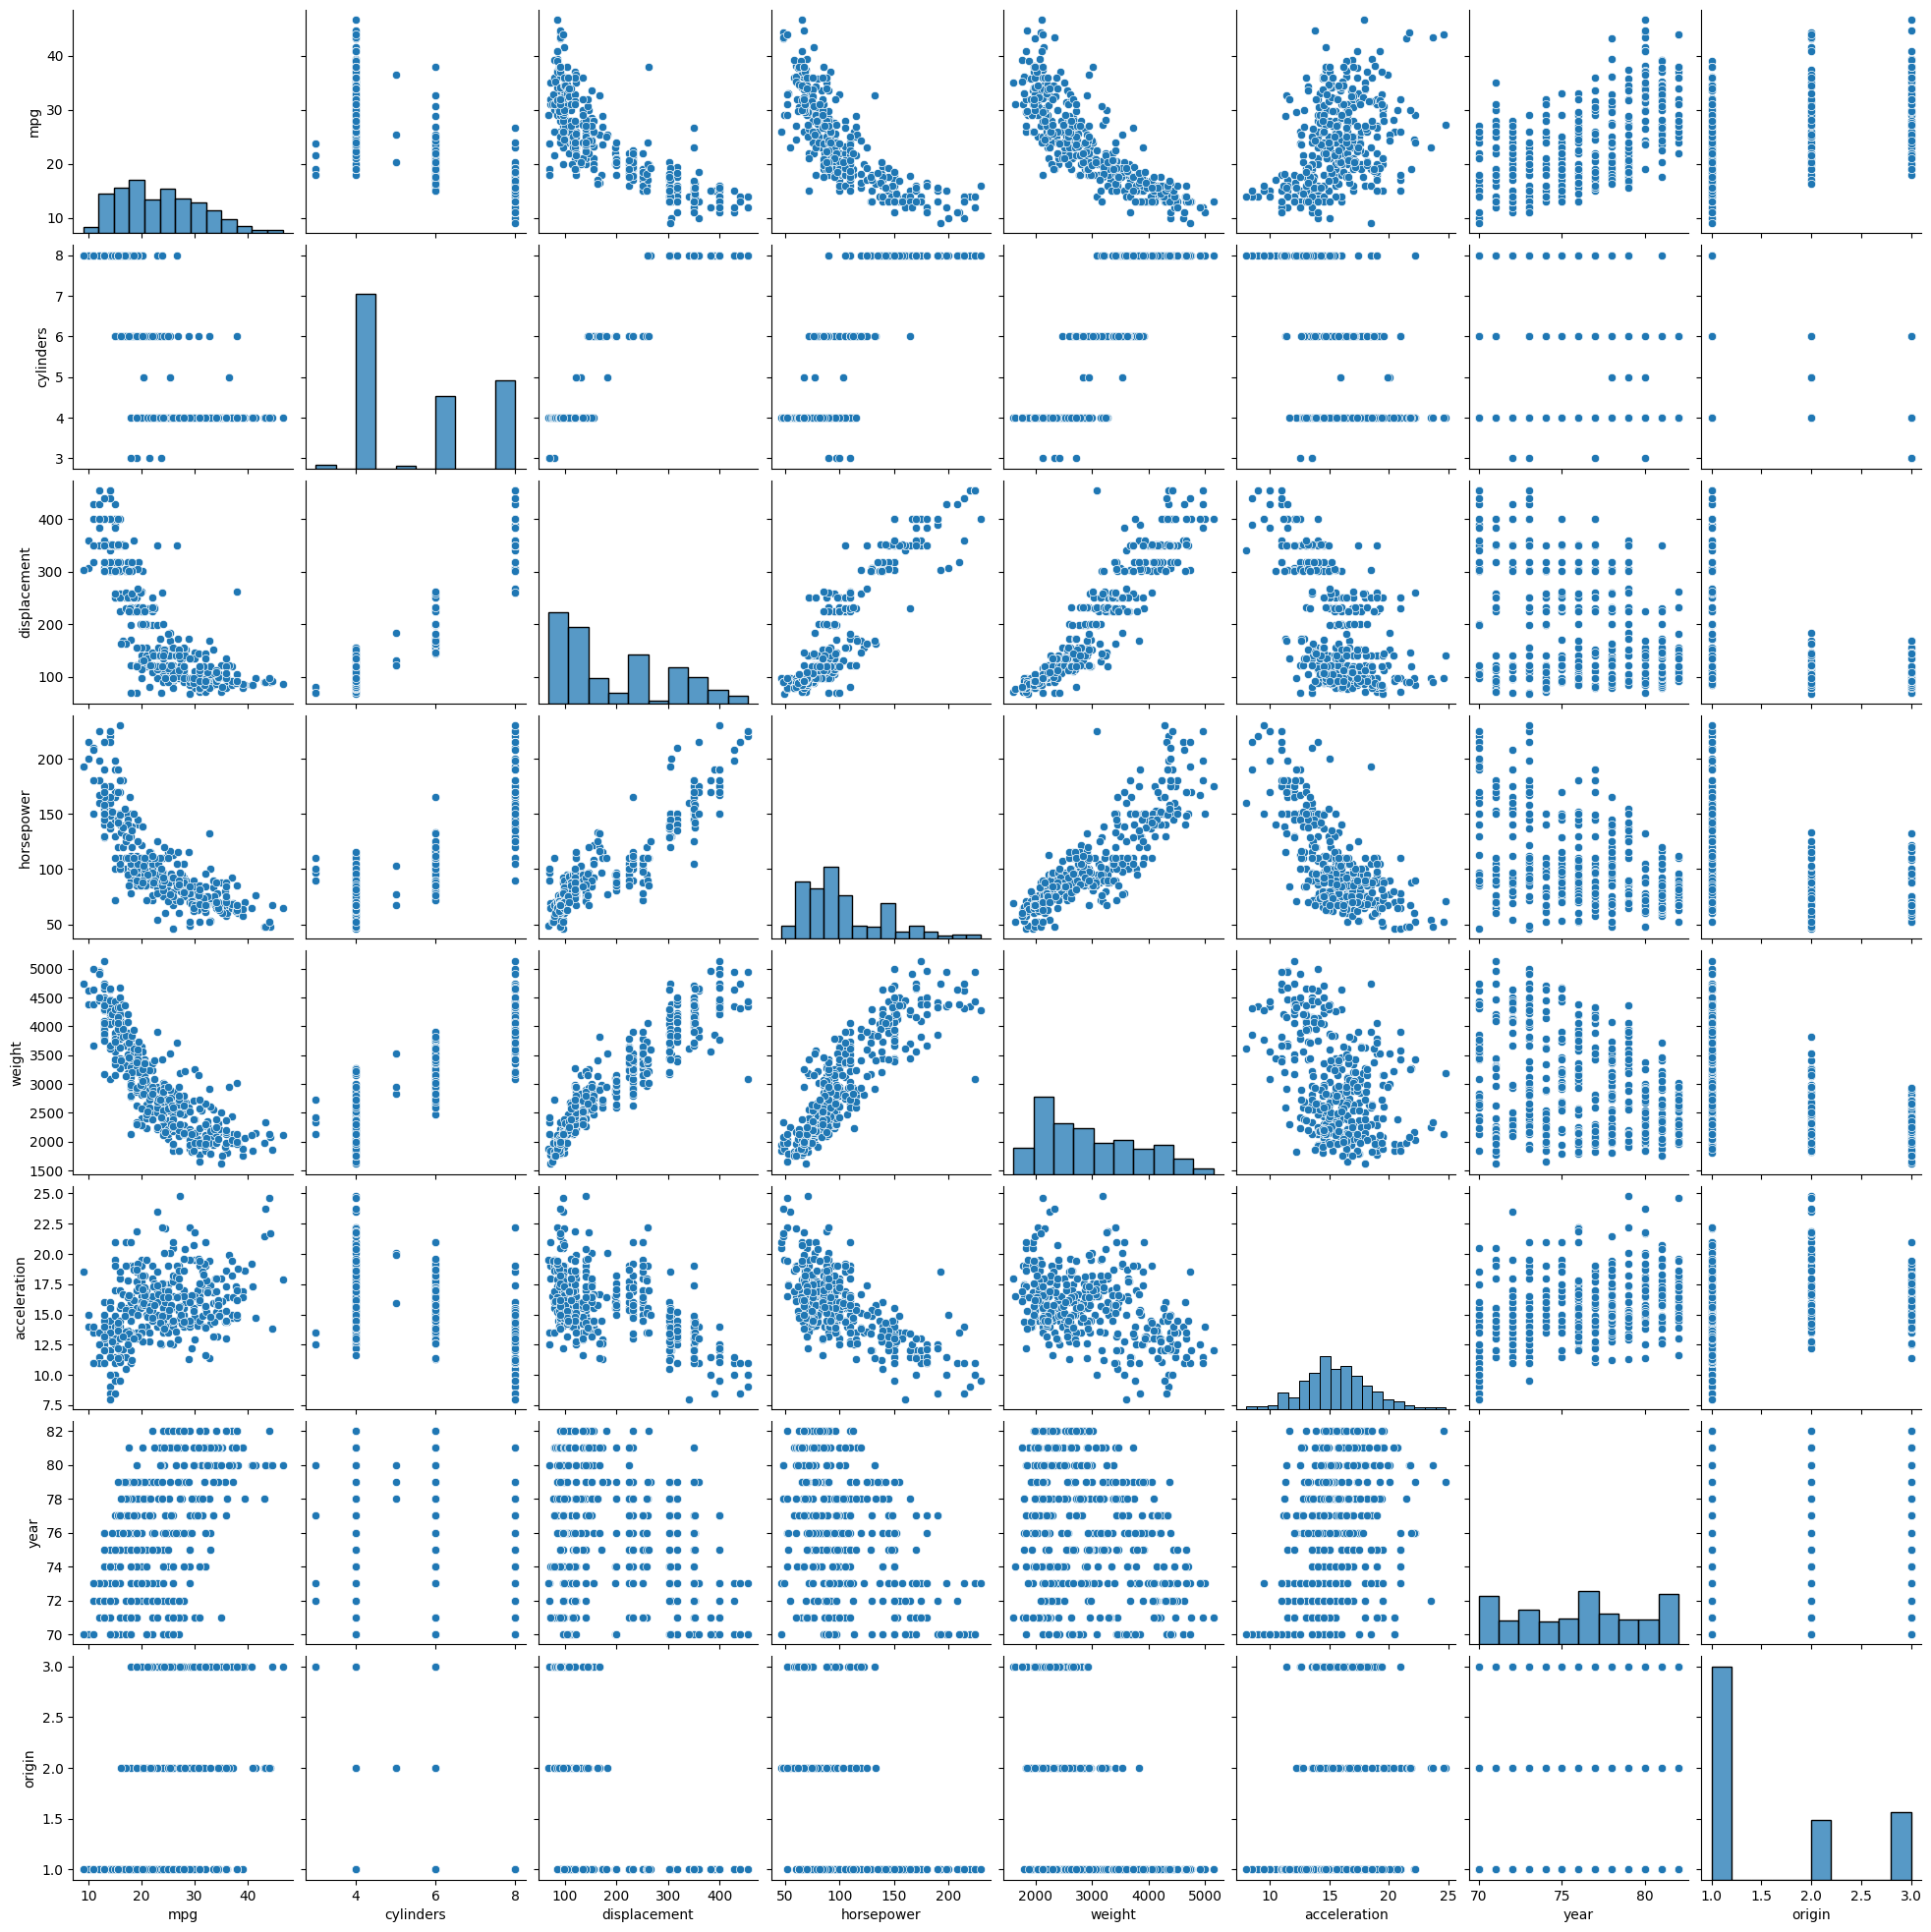

In [26]:
sns.pairplot(data)
plt.show()

## (b) ompute the matrix of correlations between the variables using the DataFrame.corr() method. .corr()

In [27]:
numeric_data = data.select_dtypes(include=np.number)
correlation_matrix = numeric_data.corr()

def color_correlations(value):
    if value == 1.0:
        return 'color: gray'
    elif abs(value) > 0.7:
        return 'color: #ff9999'
    elif abs(value) >= 0.3 and abs(value) <= 0.7:
        return 'color: yellow'
    return ''

styled_correlation_matrix = correlation_matrix.style.map(color_correlations)
display(styled_correlation_matrix)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.776260,-0.804443,-0.778427,-0.831739,0.422297,0.581469,0.563698
cylinders,-0.776260,1.000000,0.950920,0.842983,0.897017,-0.504061,-0.346717,-0.564972
displacement,-0.804443,0.950920,1.000000,0.897257,0.933104,-0.544162,-0.369804,-0.610664
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.831739,0.897017,0.933104,0.864538,1.000000,-0.419502,-0.307900,-0.581265
acceleration,0.422297,-0.504061,-0.544162,-0.689196,-0.419502,1.000000,0.282901,0.210084
year,0.581469,-0.346717,-0.369804,-0.416361,-0.307900,0.282901,1.000000,0.184314
origin,0.563698,-0.564972,-0.610664,-0.455171,-0.581265,0.210084,0.184314,1.000000


## (c) Use the sm.OLS() function to perform a multiple linear regression with mpg as the response and all other variables except name as the predictors. Use the summarize() function to print the results. Comment on the output. For instance:
### i. Is there a relationship between the predictors and the re￾sponse? Use the anova_lm() function from statsmodels to answer this question.

Based on the output from executing `anova_lm()`, we can observe the F-statistics for each variable and their corresponding P-values (`PR(>F)`).  

Since the overall F-statistic from the model (\( F = 252.4, p < 0.05 \)) is highly significant, we reject \( H_0 \) and conclude that there **is a statistically significant relationship** between the predictors and the dependent variable `mpg`.

### ii. Which predictors appear to have a statistically signifcant relationship to the response?

Assuming a significance level of α = 0.05 as the threshold, the null hypothesis \( H_0 \) is that there is no significant relationship between each independent variable and the dependent variable.

According to the OLS summary output:

- **year**, **weight**, **displacement**, and **origin** have P-values less than 0.05, indicating statistically significant relationships with `mpg`.  
- **cylinders**, **horsepower**, and **acceleration** have P-values greater than 0.05, suggesting that their effects are not statistically significant after accounting for other variables.

These results are consistent with the findings from `anova_lm()`, confirming that while most predictors contribute significantly to the model, only a subset remains statistically significant when controlling for multicollinearity.  
Overall, the model captures a strong relationship between `mpg` and several key predictors, particularly `year` (positive effect) and `weight` (negative effect).
### iii. What does the coefcient for the year variable suggest?

The regression coefficient for **`year`** is **0.7508**, with a p-value < 0.001,  
indicating that it is highly statistically significant at the 0.05 level.

This suggests that, after controlling for other variables (such as weight, displacement, etc.),  
**each additional year in the model year of the car is associated with an average increase of approximately 0.75 in `mpg`**.  

In other words, as cars become newer, their fuel efficiency improves significantly,  
which reasonably reflects technological advancements in engine performance and fuel-saving technologies over time.

In [28]:
data_cleaned = data.replace('?', np.nan)
data_cleaned['horsepower'] = pd.to_numeric(data_cleaned['horsepower'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])

X = data_cleaned[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']]
y = data_cleaned['mpg']

model = smf.ols('mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin', data=data_cleaned).fit()
print("\nModel with Sqrt(Horsepower) Transformation:")
print(model.summary())


Model with Sqrt(Horsepower) Transformation:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.04e-139
Time:                        05:09:14   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Int

In [29]:
from statsmodels.stats.anova import anova_lm

print(anova_lm(model))

                 df        sum_sq       mean_sq            F         PR(>F)
cylinders       1.0  14403.083079  14403.083079  1300.683788  2.319511e-125
displacement    1.0   1073.344025   1073.344025    96.929329   1.530906e-20
horsepower      1.0    403.408069    403.408069    36.430140   3.731128e-09
weight          1.0    975.724953    975.724953    88.113748   5.544461e-19
acceleration    1.0      0.966071      0.966071     0.087242   7.678728e-01
year            1.0   2419.120249   2419.120249   218.460900   1.875281e-39
origin          1.0    291.134494    291.134494    26.291171   4.665681e-07
Residual      384.0   4252.212530     11.073470          NaN            NaN


## (d) Produce some of diagnostic plots of the linear regression ft as described in the lab. Comment on any problems you see with the ft. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

## Result

From the **Residuals vs Fitted** plot, the residuals should ideally be randomly scattered around the horizontal line at *y = 0*.  
However, the red trend line shows a clear U-shaped pattern, suggesting that the residuals are not randomly distributed and that the model may not fully capture the nonlinear relationship between predictors and *mpg*.

In the **Normal Q–Q** plot, most residuals follow the theoretical normal line, but several outliers appear in the upper tail, indicating the presence of extreme observations with unusually high *mpg* values.

The **Scale–Location** plot shows a slight increase in residual variance as the fitted values increase, implying heteroscedasticity — the model errors are not constant across levels of *mpg*.

In the **Residuals vs Leverage** plot, most points lie within the ±3 range, showing reasonable fit overall.  
However, point **13** has very high leverage, indicating strong influence on the regression line, while points **322** and **326** have large residuals and may be outliers.

---

Potential outliers (std resid > 3): [242 320 323 324]

High leverage points: [  6   7   8  12  13  25  26  27  28  93  94 115 209 297 298 359 388]

---

## Conclusion

- The residuals are not randomly distributed, suggesting the model may need improvement.  
- Some residual outliers appear at higher fitted values; overall normality is acceptable, but a few extreme high-mpg cases exist.  
- The variance of residuals increases with fitted values, violating the homoscedasticity assumption.  
- Certain points (e.g., **13, 322, 326**) exert strong or abnormal influence on the model and should be further inspected.  
- To improve the model fit, we may introduce nonlinear terms (e.g., squared, square root, or log transformations) or consider weighted regression.

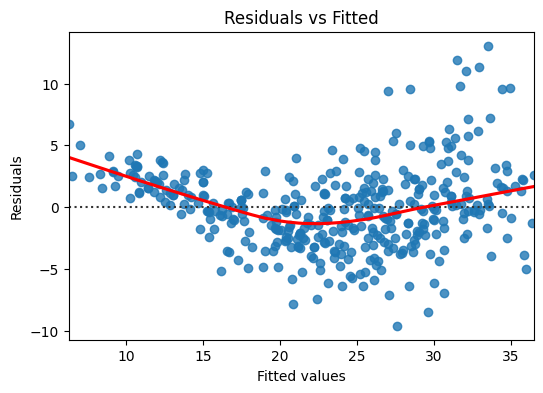

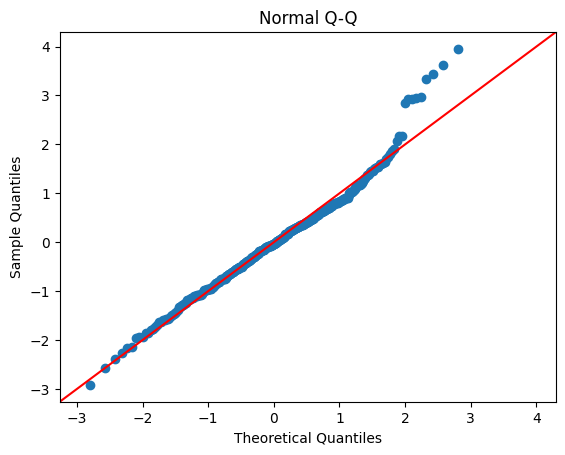

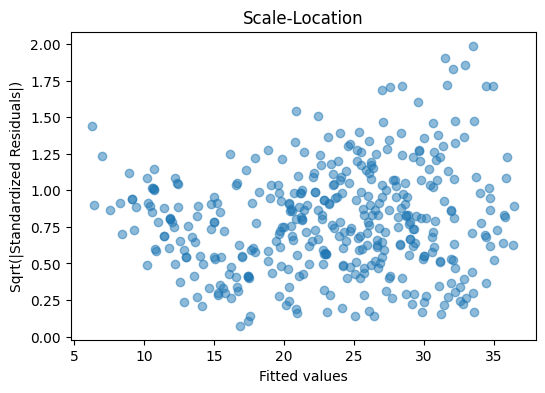

<Figure size 800x600 with 0 Axes>

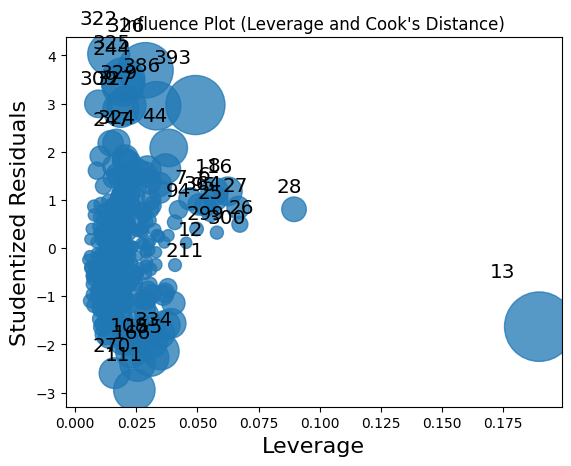


Potential outliers (std resid > 3): [242 320 323 324]
High leverage points: [  6   7   8  12  13  25  26  27  28  93  94 115 209 297 298 359 388]


In [30]:
fitted_vals = model.fittedvalues
residuals = model.resid
standardized_resid = model.get_influence().resid_studentized_internal

# ------------------------------
# 1. Residuals vs Fitted
# ------------------------------
plt.figure(figsize=(6,4))
sns.residplot(x=fitted_vals, y=residuals, lowess=True, line_kws={'color':'red'})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# ------------------------------
# 2. Normal Q-Q plot
# ------------------------------
sm.qqplot(standardized_resid, line='45')
plt.title("Normal Q-Q")
plt.show()

# ------------------------------
# 3. Scale-Location plot
# ------------------------------
plt.figure(figsize=(6,4))
plt.scatter(fitted_vals, np.sqrt(np.abs(standardized_resid)), alpha=0.5)
plt.xlabel("Fitted values")
plt.ylabel("Sqrt(|Standardized Residuals|)")
plt.title("Scale-Location")
plt.show()

# ------------------------------
# 4. Influence / Leverage plot
# ------------------------------
plt.figure(figsize=(8,6))
influence_plot(model, criterion="cooks", size=50)
plt.title("Influence Plot (Leverage and Cook's Distance)")
plt.show()

influence = model.get_influence()
cooks = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

outliers = np.where(np.abs(standardized_resid) > 3)[0]  # residuals > 3 std dev
high_leverage = np.where(leverage > 2 * (model.df_model + 1)/len(data_cleaned))[0]

print("\nPotential outliers (std resid > 3):", outliers)
print("High leverage points:", high_leverage)

## (e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

### Result

In this case, I tried adding the following interaction terms to the model:

- Multiplying **weight** and **year** (`weight * year`)
- Multiplying **horsepower** and **cylinders** (`horsepower * cylinders`)

From these two interaction models:

- The original predictors **weight** and **year**, which were already highly correlated with `mpg`, remain significant.
- The interaction term **weight:year** is statistically significant (**p < 0.001**), suggesting that the effect of weight on `mpg` changes depending on the car's model year.
- For **horsepower** and **cylinders**, which individually had high p-values in the simpler model, the interaction **cylinders:horsepower** is highly significant (**p < 0.001**), indicating that the effect of horsepower on `mpg` depends on the number of cylinders.

Overall, adding interaction terms improves the model fit and reveals relationships not captured by the main effects alone.
These results demonstrate that **interactions between predictors can be important** and should be considered when modeling `mpg`.

In [31]:
import statsmodels.formula.api as smf

data_cleaned = data.replace('?', np.nan)
data_cleaned['horsepower'] = pd.to_numeric(data_cleaned['horsepower'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])

# Model with weight * year interaction
model_with_interaction_wy = smf.ols('mpg ~ cylinders + displacement + horsepower + weight * year + acceleration + origin', data=data_cleaned).fit()
print("\nModel with Weight * Year Interaction:")
print(model_with_interaction_wy.summary())

# Model with horsepower * cylinders interaction
model_with_interaction_hc = smf.ols('mpg ~ cylinders * horsepower + displacement + weight + acceleration + year + origin', data=data_cleaned).fit()
print("\n\n\n\n\nModel with Horsepower * Cylinders Interaction:")
print(model_with_interaction_hc.summary())


Model with Weight * Year Interaction:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     265.1
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          5.11e-151
Time:                        05:09:15   Log-Likelihood:                -993.17
No. Observations:                 392   AIC:                             2004.
Df Residuals:                     383   BIC:                             2040.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept

## (f) Try a few different transformations of the variables, such as log(X), √X, X². Comment on your findings.

### Result

1. **Log(Weight) Transformation**
   - `log_weight` has a significant effect (p < 0.001).  
   - Model R-squared increases to 0.846, indicating slightly better explanatory power.

2. **√Horsepower Transformation**
   - `sqrt_horsepower` significantly affects mpg (p < 0.001).  
   - R-squared is 0.827, similar to the original model.

3. **Displacement² Transformation**
   - `displacement_squared` is significant (p < 0.001).  
   - R-squared increases to 0.836, showing slight improvement in fit.

4. **Horsepower² Transformation**
   - `horsepower²` is not significant (p = 0.220).  
   - R-squared remains the same as the original model, indicating no notable improvement.
   - R-squared 與原模型相同，表示無明顯改善。

### Conclude
- Transformations like `log(weight)`, `√horsepower`, and `displacement²` can improve model fit and capture nonlinear effects.  
- Some transformations, like `horsepower²`, do not provide meaningful improvements.  
- These findings suggest that certain predictors have nonlinear relationships with fuel efficiency, and applying appropriate transformations can help improve model accuracy.

In [32]:
import statsmodels.formula.api as smf
import numpy as np

data_cleaned = data.replace('?', np.nan)
data_cleaned['horsepower'] = pd.to_numeric(data_cleaned['horsepower'], errors='coerce')
data_cleaned = data_cleaned.dropna(subset=['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin'])

data_cleaned['log_weight'] = np.log(data_cleaned['weight'])
data_cleaned['sqrt_horsepower'] = np.sqrt(data_cleaned['horsepower'])
data_cleaned['displacement_squared'] = data_cleaned['displacement']**2

model_with_transformation = smf.ols('mpg ~ cylinders + displacement + horsepower + log_weight + acceleration + year + origin', data=data_cleaned).fit()
print("\nModel with Log(Weight) Transformation:")
print(model_with_transformation.summary())

model_with_transformation = smf.ols('mpg ~ cylinders + displacement + sqrt_horsepower + weight + acceleration + year + origin', data=data_cleaned).fit()
print("\n\n\n\n\nModel with Sqrt(Horsepower) Transformation:")
print(model_with_transformation.summary())

model_with_transformation = smf.ols('mpg ~ cylinders + displacement_squared + horsepower + weight + acceleration + year + origin', data=data_cleaned).fit()
print("\n\n\n\n\nModel with Displacement^2 Transformation:")
print(model_with_transformation.summary())

model_with_transformation = smf.ols('mpg ~ cylinders + displacement + horsepower**2 + weight + acceleration + year + origin', data=data_cleaned).fit()
print("\n\n\n\n\nModel with Horsepower^2 Transformation:")
print(model_with_transformation.summary())


Model with Log(Weight) Transformation:
                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.846
Model:                            OLS   Adj. R-squared:                  0.843
Method:                 Least Squares   F-statistic:                     301.2
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          1.13e-151
Time:                        05:09:15   Log-Likelihood:                -994.59
No. Observations:                 392   AIC:                             2005.
Df Residuals:                     384   BIC:                             2037.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercep